# **Ejercicio**

****El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

- Lleva a cabo el análisis exploratorio de datos
- Identificar operadores ineficaces
- Prueba las hipótesis estadísticas

### Descripción de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

 

El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

Haz una lista de 5 a 10 fuentes (documentación, artículos, etc) que usaste mientras trabajabas en el proyecto. Brinda explicaciones breves sobre las preguntas que cada fuente te ayudó a responder. Prepara una presentación con tus conclusiones. Puedes usar cualquier herramienta que quieras para hacer la presentación, pero debes enviarla en PDF. Coloca el enlace en el cuerpo del proyecto principal.

# **1.Librerías**

In [1]:
import pandas as pd
from scipy import stats as st
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math as mt
from math import factorial
import seaborn as sns
import datetime
import matplotlib.ticker as mtick


# **2. Llevar a cabo el análisis exploratorio de datos (EDA)**

### **2.1.Cargar y examinar el dataset de telecomunicaciones**

### **Clients**

In [2]:
df_clients = pd.read_csv("telecom_clients.csv")
df_dataset = pd.read_csv("telecom_dataset_new.csv")

In [3]:
df_clients.head(10)

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
5,167764,A,2019-09-30
6,167050,A,2019-08-29
7,168252,A,2019-10-17
8,168495,A,2019-10-28
9,167879,A,2019-10-03


In [4]:
df_clients.shape

(732, 3)

In [5]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [6]:
# Ver qué planes tarifarios existen
print("Planes tarifarios disponibles:")
print(df_clients['tariff_plan'].value_counts())

Planes tarifarios disponibles:
C    395
B    261
A     76
Name: tariff_plan, dtype: int64


In [7]:
# Convertir date_start a datetime si no lo está
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

# Ver el rango de fechas
print(f"Fecha más antigua: {df_clients['date_start'].min()}")
print(f"Fecha más reciente: {df_clients['date_start'].max()}")

Fecha más antigua: 2019-08-01 00:00:00
Fecha más reciente: 2019-10-31 00:00:00


### **Dataset**

In [8]:
df_dataset.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [9]:
df_dataset.shape

(53902, 9)

In [10]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [11]:
# Ver cuántos registros tienen operator_id nulo
nulos_operator = df_dataset['operator_id'].isnull().sum()
total_registros = len(df_dataset)
porcentaje_nulos = (nulos_operator / total_registros) * 100

print(f"Registros con operator_id nulo: {nulos_operator}")
print(f"Total de registros: {total_registros}")
print(f"Porcentaje de nulos: {porcentaje_nulos:.2f}%")

Registros con operator_id nulo: 8172
Total de registros: 53902
Porcentaje de nulos: 15.16%


In [12]:
# Crear un subset con solo los registros que tienen operator_id nulo
registros_nulos = df_dataset[df_dataset['operator_id'].isnull()]

print("=== ANÁLISIS DE REGISTROS SIN OPERATOR_ID ===")
print(f"Total de registros nulos: {len(registros_nulos)}")
print()

# Ver las primeras filas para entender el patrón
print("Primeras 10 filas con operator_id nulo:")
display(registros_nulos.head(10))

=== ANÁLISIS DE REGISTROS SIN OPERATOR_ID ===
Total de registros nulos: 8172

Primeras 10 filas con operator_id nulo:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
30,166377,2019-08-13 00:00:00+03:00,in,False,NaN,True,7,0,128
38,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
77,166377,2019-08-22 00:00:00+03:00,in,False,NaN,True,1,0,1


In [13]:
# ¿Qué tipo de llamadas son las que no tienen operator_id?
print("Distribución por dirección de llamada (in/out):")
print(registros_nulos['direction'].value_counts())
print()

# Calcular porcentajes
direccion_porcentajes = registros_nulos['direction'].value_counts(normalize=True) * 100
print("Porcentajes:")
for direccion, porcentaje in direccion_porcentajes.items():
    print(f"{direccion}: {porcentaje:.2f}%")

Distribución por dirección de llamada (in/out):
in     7972
out     200
Name: direction, dtype: int64

Porcentajes:
in: 97.55%
out: 2.45%


In [14]:
# ¿Son llamadas internas las que no tienen operator_id?
print("¿Son llamadas internas?")
print(registros_nulos['internal'].value_counts())

¿Son llamadas internas?
False    7760
True      355
Name: internal, dtype: int64


### **2.2.Identificar variables relacionadas con operadores**

In [15]:
# Filtrar datos válidos para análisis de operadores
df_operadores = df_dataset[df_dataset['operator_id'].notna()]

# Validación
print("Registros originales:", len(df_dataset))
print("Registros con operador:", len(df_operadores))
print("Registros sin operador:", df_dataset['operator_id'].isna().sum())

Registros originales: 53902
Registros con operador: 45730
Registros sin operador: 8172


### **2.3.Analizar métricas de rendimiento por operador**

In [16]:
# =========================================
# MÉTRICAS CLAVE POR OPERADOR
# =========================================

# 1. Agrupar por operador y calcular métricas básicas
metricas = df_operadores.groupby('operator_id').agg(
    num_llamadas=('call_duration', 'count'),     # volumen de llamadas
    duracion_promedio=('call_duration', 'mean'), # duración promedio
    duracion_total=('call_duration', 'sum')      # tiempo total trabajado
).reset_index()

# 2. Crear indicador simple de ineficiencia
# (más alto = peor desempeño)
metricas['score_ineficiencia'] = (
    metricas['duracion_promedio'] / metricas['num_llamadas']
)

# 3. Identificar operadores problemáticos
top_ineficientes = metricas.sort_values(
    by='score_ineficiencia', ascending=False
).head(10)

# 4. Mostrar resultados
print("Top operadores potencialmente ineficientes:")
display(top_ineficientes)

# 5. Vista general
metricas.head()

Top operadores potencialmente ineficientes:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
326,909452.0,1,3394.000000,3394,3394.000000
1073,969600.0,3,4190.000000,12570,1396.666667
74,891192.0,1,1306.000000,1306,1306.000000
140,896386.0,2,2068.000000,4136,1034.000000
547,925134.0,2,1847.500000,3695,923.750000
169,899906.0,1,626.000000,626,626.000000
731,938070.0,8,4235.625000,33885,529.453125
1053,965544.0,13,6053.923077,78701,465.686391
945,952292.0,1,451.000000,451,451.000000
1084,971102.0,5,2125.600000,10628,425.120000


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
0,879896.0,128,650.476562,83261,5.081848
1,879898.0,251,1111.067729,278878,4.426565
2,880020.0,22,104.090909,2290,4.731405
3,880022.0,76,240.842105,18304,3.168975
4,880026.0,198,856.939394,169674,4.327977


In [17]:
# Explorar las variables categóricas
print("Distribución de direction:")
print(df_operadores['direction'].value_counts())
print("\nDistribución de internal:")
print(df_operadores['internal'].value_counts())
print("\nDistribución de is_missed_call:")
print(df_operadores['is_missed_call'].value_counts())

Distribución de direction:
out    31717
in     14013
Name: direction, dtype: int64

Distribución de internal:
False    39861
True      5809
Name: internal, dtype: int64

Distribución de is_missed_call:
False    30212
True     15518
Name: is_missed_call, dtype: int64


### **2.4.Crear visualizaciones descriptivas**

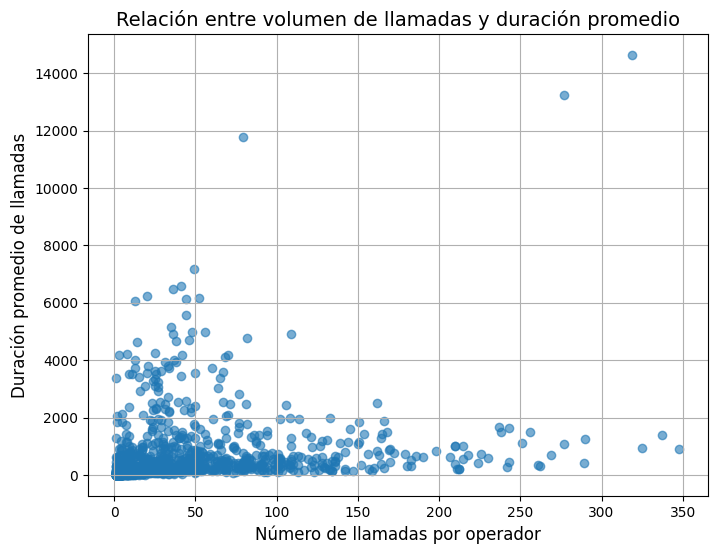

In [18]:
#Scatter: volumen vs eficiencia
plt.figure(figsize=(8,6))  # tamaño más grande

plt.scatter(
    metricas['num_llamadas'],
    metricas['duracion_promedio'],
    alpha=0.6  # transparencia para ver densidad
)

# Etiquetas y título claros
plt.title("Relación entre volumen de llamadas y duración promedio", fontsize=14)
plt.xlabel("Número de llamadas por operador", fontsize=12)
plt.ylabel("Duración promedio de llamadas", fontsize=12)

# Cuadrícula para mejor lectura
plt.grid(True)

plt.show()

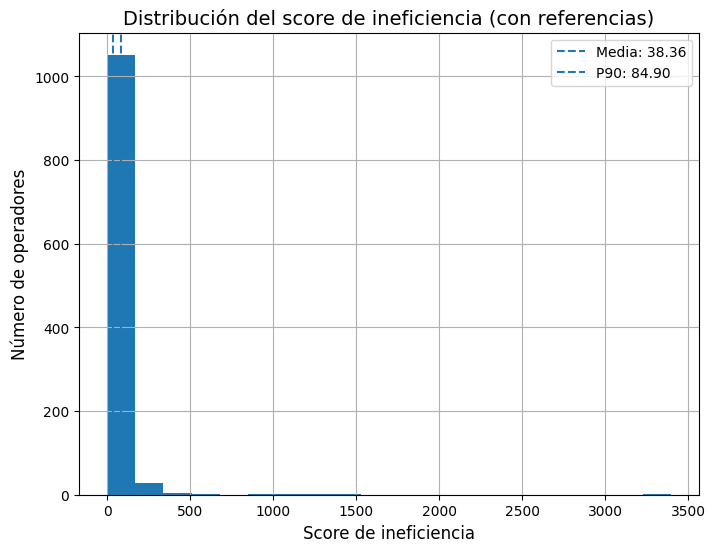

In [19]:
#Histograma del score de ineficiencia
plt.figure(figsize=(8,6))

n, bins, patches = plt.hist(
    metricas['score_ineficiencia'],
    bins=20
)

# Línea de promedio
media = metricas['score_ineficiencia'].mean()
plt.axvline(media, linestyle='--', label=f'Media: {media:.2f}')

# Línea de percentil 90 (ineficientes)
p90 = metricas['score_ineficiencia'].quantile(0.9)
plt.axvline(p90, linestyle='--', label=f'P90: {p90:.2f}')

# Títulos y etiquetas
plt.title("Distribución del score de ineficiencia (con referencias)", fontsize=14)
plt.xlabel("Score de ineficiencia", fontsize=12)
plt.ylabel("Número de operadores", fontsize=12)

# Leyenda (esto faltaba 👈)
plt.legend()

# Grid
plt.grid(True)

plt.show()

Ineficientes: 37
Resto: 45693


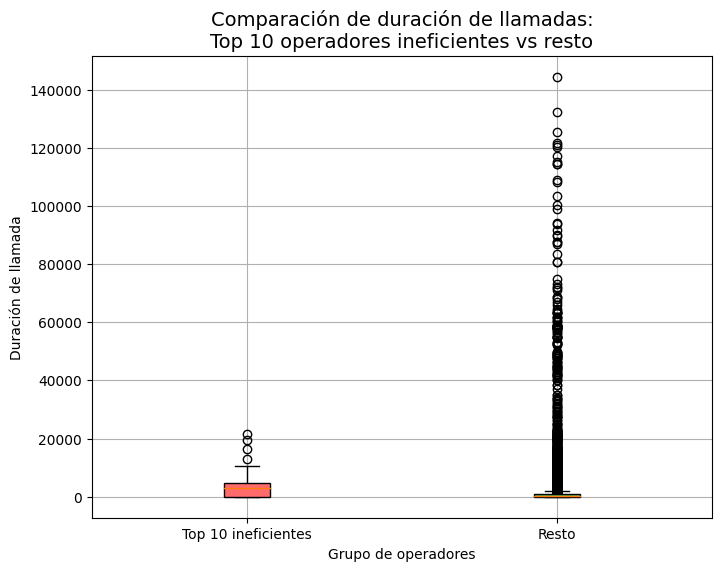

In [20]:

# Boxplot: top vs resto
top_ids = metricas.sort_values(
    by='score_ineficiencia', ascending=False
)['operator_id'].head(10)

# Creación de columna "grupo"
df_operadores = df_operadores.copy()

df_operadores['grupo'] = df_operadores['operator_id'].apply(
    lambda x: 'Top 10 ineficientes' if x in top_ids.values else 'Resto'
)

# Filtrar correctamente 
grupo_ineficientes = df_operadores[df_operadores['grupo'].str.contains('Top')]['call_duration']
grupo_resto = df_operadores[df_operadores['grupo'].str.contains('Resto')]['call_duration']

# Verificar que no estén vacíos
print("Ineficientes:", len(grupo_ineficientes))
print("Resto:", len(grupo_resto))

# Crear figura
plt.figure(figsize=(8,6))

# Crear boxplot - AQUÍ ESTÁ EL CAMBIO
box = plt.boxplot(
    [grupo_ineficientes, grupo_resto],
    labels=['Top 10 ineficientes', 'Resto'],  # Cambié tick_labels por labels
    patch_artist=True
)

# Colorear cajas
colors = ['#FF6B6B', '#4CAF50']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Títulos y etiquetas
plt.title("Comparación de duración de llamadas:\nTop 10 operadores ineficientes vs resto", fontsize=14)
plt.xlabel("Grupo de operadores")
plt.ylabel("Duración de llamada")

# Grid
plt.grid(True)

plt.show()


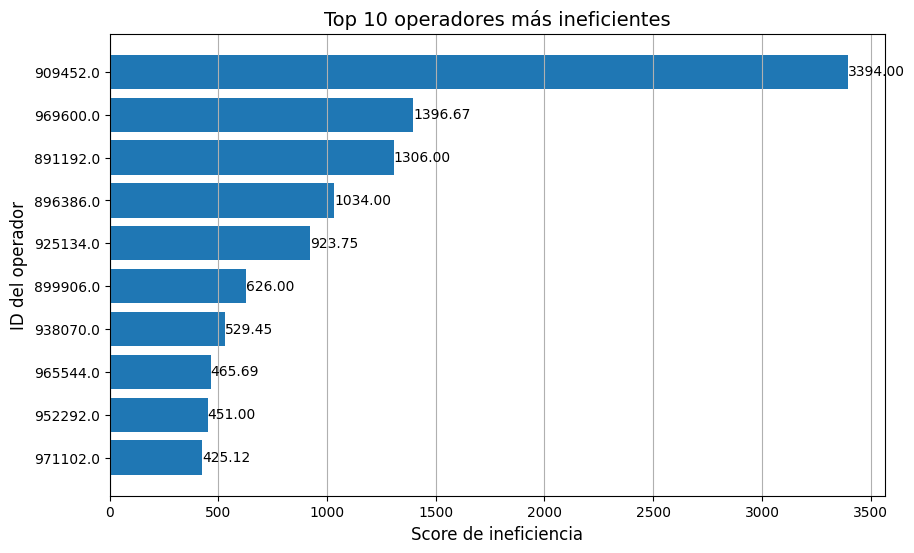

In [21]:
# Rankin Visual
# Ordenar correctamente (de menor a mayor para mejor visual en horizontal)
top10 = metricas.sort_values(
    by='score_ineficiencia', ascending=True
).tail(10)

plt.figure(figsize=(10,6))

# Crear barras
bars = plt.barh(
    top10['operator_id'].astype(str),
    top10['score_ineficiencia']
)

# Agregar etiquetas de valor en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=10
    )

# Títulos y etiquetas 
plt.title("Top 10 operadores más ineficientes", fontsize=14)
plt.xlabel("Score de ineficiencia", fontsize=12)
plt.ylabel("ID del operador", fontsize=12)

# Grid para mejor lectura
plt.grid(axis='x')

plt.show()

**🔵 1. Scatter: Número de llamadas vs duración promedio**

Conclusión:

Se observa una relación variable entre el volumen de llamadas y la duración promedio. Algunos operadores con alto número de llamadas mantienen duraciones bajas, lo que sugiere eficiencia operativa. Sin embargo, también se identifican operadores con pocas llamadas pero tiempos elevados, lo que podría indicar ineficiencia o problemas en la gestión de llamadas.

👉 Insight clave:

No todos los operadores con alta carga son ineficientes
Los casos críticos están en duraciones altas, no en volumen

**🟡 2. Histograma: Distribución del score de ineficiencia**

Conclusión:

La distribución del score de ineficiencia muestra que la mayoría de los operadores se concentra en rangos medios, mientras que un pequeño grupo presenta valores significativamente más altos. Estos operadores representan casos atípicos que requieren atención prioritaria.

👉 Insight clave:

La ineficiencia no es generalizada
Existe un grupo específico problemático (outliers)

**🔴 3. Boxplot: Top 10 vs resto**

Conclusión:

Los operadores clasificados dentro del top 10 de ineficiencia presentan una mayor duración de llamadas y mayor dispersión en comparación con el resto. Esto indica no solo un desempeño más lento, sino también inconsistencia en la atención.

👉 Insight clave:

Los operadores ineficientes:
atienden más lento
son menos consistentes

**🟣 4. Bar chart: Top 10 operadores ineficientes**

Conclusión:

El ranking de operadores permite identificar claramente a los individuos con mayor nivel de ineficiencia. Se observa una diferencia significativa entre los operadores más críticos y el resto, lo que facilita la priorización de acciones correctivas.

👉 Insight clave:

Puedes actuar directamente sobre casos específicos
Hay diferencias claras entre operadores

### **2.5.Matriz de correlación**

In [22]:
columnas_numericas = ['num_llamadas', 'duracion_promedio', 'duracion_total', 'score_ineficiencia']
corr_matrix = metricas[columnas_numericas].corr()
corr_matrix

,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
num_llamadas,1.000000,0.234307,0.413758,-0.129578
duracion_promedio,0.234307,1.000000,0.673099,0.292459
duracion_total,0.413758,0.673099,1.000000,0.008664
score_ineficiencia,-0.129578,0.292459,0.008664,1.000000


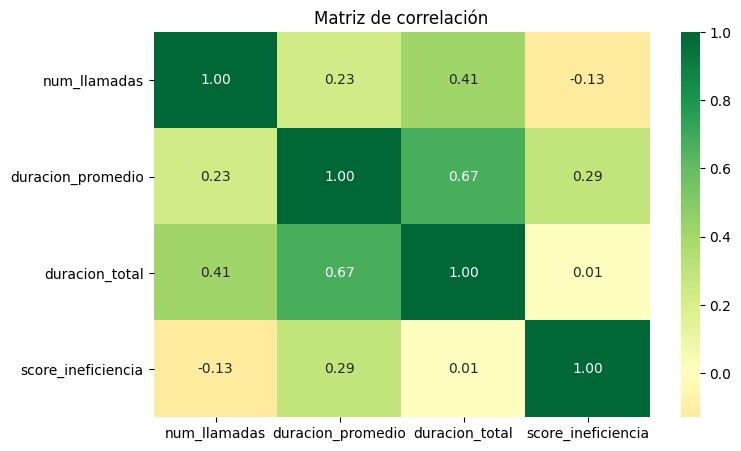

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriz de correlación')
plt.show()


El análisis de correlación muestra que la ineficiencia de los operadores no depende del volumen de trabajo, sino principalmente de la duración promedio de las llamadas. Esto sugiere que los problemas de desempeño están más relacionados con la gestión del tiempo durante cada interacción que con la cantidad de llamadas atendidas.

# **3. Definición de Métricas de Eficiencia**

### **3.1.Establecer KPIs**

In [24]:
# Agrupar datos por operador y calcular métricas clave
metricas = df_operadores.groupby('operator_id').agg(
    num_llamadas=('call_duration', 'count'),     # volumen de llamadas
    duracion_promedio=('call_duration', 'mean'), # tiempo promedio por llamada
    duracion_total=('call_duration', 'sum')      # tiempo total trabajado
).reset_index()

# Crear score de ineficiencia
metricas['score_ineficiencia'] = (
    metricas['duracion_promedio'] / metricas['num_llamadas']
)

# Visualizar resultados
metricas.head()

,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
0,879896.0,128,650.476562,83261,5.081848
1,879898.0,251,1111.067729,278878,4.426565
2,880020.0,22,104.090909,2290,4.731405
3,880022.0,76,240.842105,18304,3.168975
4,880026.0,198,856.939394,169674,4.327977


### **3.2.Definir umbrales de rendimiento**

In [25]:
# Calcular percentiles del score
p10 = metricas['score_ineficiencia'].quantile(0.10)
p90 = metricas['score_ineficiencia'].quantile(0.90)

print(f"Percentil 10 (eficientes): {p10:.4f}")
print(f"Percentil 90 (ineficientes): {p90:.4f}")

Percentil 10 (eficientes): 2.1876
Percentil 90 (ineficientes): 84.9040


### **3.3.Definir criterios de ineficacia**

In [26]:
# Crear columna de categoría
metricas['categoria'] = 'Promedio'

# Clasificar operadores ineficientes
metricas.loc[
    metricas['score_ineficiencia'] >= p90,
    'categoria'
] = 'Ineficiente'

# Clasificar operadores eficientes
metricas.loc[
    metricas['score_ineficiencia'] <= p10,
    'categoria'
] = 'Eficiente'

# Ver distribución
metricas['categoria'].value_counts()

Promedio       872
Eficiente      110
Ineficiente    110
Name: categoria, dtype: int64

In [27]:
# Ver ejemplos de cada grupo
print("\nOperadores ineficientes:")
display(metricas[metricas['categoria'] == 'Ineficiente'].head())

print("\nOperadores eficientes:")
display(metricas[metricas['categoria'] == 'Eficiente'].head())


Operadores ineficientes:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
55,890234.0,1,85.000000,85,85.000000,Ineficiente
74,891192.0,1,1306.000000,1306,1306.000000,Ineficiente
75,891250.0,1,110.000000,110,110.000000,Ineficiente
91,891970.0,3,368.666667,1106,122.888889,Ineficiente
139,896384.0,4,866.000000,3464,216.500000,Ineficiente



Operadores eficientes:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
15,883018.0,1,0.000000,0,0.000000,Eficiente
21,884406.0,4,4.000000,16,1.000000,Eficiente
27,885682.0,3,0.000000,0,0.000000,Eficiente
31,886674.0,11,16.818182,185,1.528926,Eficiente
33,887276.0,289,442.743945,127953,1.531986,Eficiente


La definición de métricas de eficiencia permitió construir un marco analítico sólido para evaluar el desempeño de los operadores, asegurando que la identificación de ineficiencias se base en criterios objetivos, medibles y alineados con la operación real.

# **4.Análisis de Rendimiento por Operador**

### **4.1.Calcular métricas de eficiencia**

In [28]:
print("Métricas de eficiencia por operador:")
display(metricas.head())

Métricas de eficiencia por operador:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
0,879896.0,128,650.476562,83261,5.081848,Promedio
1,879898.0,251,1111.067729,278878,4.426565,Promedio
2,880020.0,22,104.090909,2290,4.731405,Promedio
3,880022.0,76,240.842105,18304,3.168975,Promedio
4,880026.0,198,856.939394,169674,4.327977,Promedio


### **4.2.Comparar rendimiento entre operadores**

In [29]:
# Aplicar formato global
pd.options.display.float_format = '{:,.2f}'.format

# Estadísticas generales
print("📊 Resumen general:")
display(metricas.describe())

# Columnas a formatear (sin operator_id)
cols_formato = ['num_llamadas', 'duracion_promedio', 'duracion_total', 'score_ineficiencia']

# Top operadores más eficientes
top_eficientes = metricas.sort_values(
    by='score_ineficiencia'
).head(5)

print("\n🟢 Operadores más eficientes:")
display(top_eficientes.style.format({
    col: "{:,.2f}" for col in cols_formato
}))

# Top operadores menos eficientes
top_ineficientes = metricas.sort_values(
    by='score_ineficiencia',
    ascending=False
).head(5)

print("\n🔴 Operadores menos eficientes:")
display(top_ineficientes.style.format({
    col: "{:,.2f}" for col in cols_formato
}))

📊 Resumen general:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
count,"1,092.00","1,092.00","1,092.00","1,092.00","1,092.00"
mean,"925,517.54",41.88,648.21,"42,286.23",38.36
std,"22,854.53",54.08,"1,195.99","191,567.65",136.88
min,"879,896.00",1.00,0.00,0.00,0.00
25%,"906,393.50",6.00,76.66,479.75,4.36
50%,"925,105.00",21.00,239.81,"5,985.00",9.74
75%,"944,211.50",54.25,659.82,"37,122.75",29.03
max,"973,286.00",348.00,"14,620.55","4,663,954.00","3,394.00"



🟢 Operadores más eficientes:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
569,928282.000000,2.00,0.00,0.00,0.00,Eficiente
697,937770.000000,1.00,0.00,0.00,0.00,Eficiente
324,909308.000000,3.00,0.00,0.00,0.00,Eficiente
666,936296.000000,3.00,0.00,0.00,0.00,Eficiente
27,885682.000000,3.00,0.00,0.00,0.00,Eficiente



🔴 Operadores menos eficientes:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
326,909452.000000,1.00,"3,394.00","3,394.00","3,394.00",Ineficiente
1073,969600.000000,3.00,"4,190.00","12,570.00","1,396.67",Ineficiente
74,891192.000000,1.00,"1,306.00","1,306.00","1,306.00",Ineficiente
140,896386.000000,2.00,"2,068.00","4,136.00","1,034.00",Ineficiente
547,925134.000000,2.00,"1,847.50","3,695.00",923.75,Ineficiente


### **4.3.Identificar patrones de ineficiencia**

📊 Matriz de correlación:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
operator_id,1.00,-0.30,0.01,-0.11,0.03
num_llamadas,-0.30,1.00,0.23,0.41,-0.13
duracion_promedio,0.01,0.23,1.00,0.67,0.29
duracion_total,-0.11,0.41,0.67,1.00,0.01
score_ineficiencia,0.03,-0.13,0.29,0.01,1.00


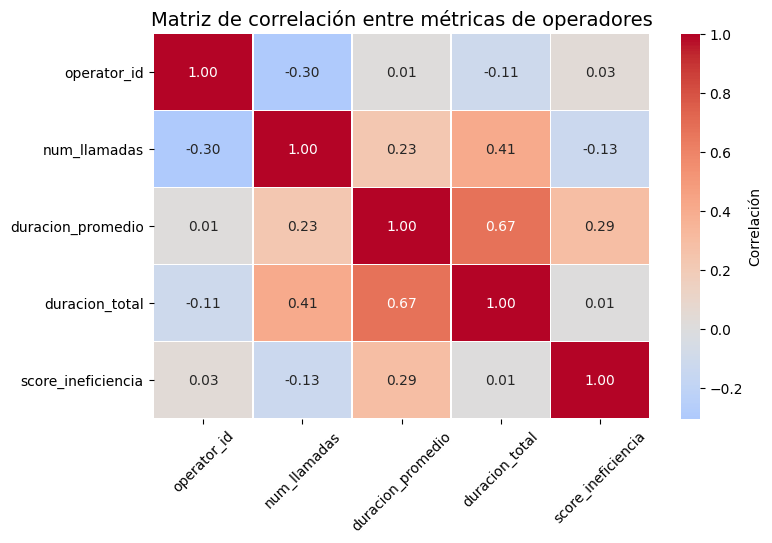


🟢 Operadores con alta duración promedio:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
0,"879,896.00",128,650.48,83261,5.08,Promedio
1,"879,898.00",251,"1,111.07",278878,4.43,Promedio
4,"880,026.00",198,856.94,169674,4.33,Promedio
5,"880,028.00",226,746.27,168656,3.30,Promedio
11,"882,684.00",165,"1,422.18",234659,8.62,Promedio



🔴 Operadores con bajo volumen de llamadas:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria
2,"880,020.00",22,104.09,2290,4.73,Promedio
6,"880,240.00",14,275.93,3863,19.71,Promedio
7,"881,278.00",8,58.12,465,7.27,Promedio
8,"882,476.00",3,64.00,192,21.33,Promedio
9,"882,478.00",3,22.67,68,7.56,Promedio


In [30]:
# Correlación entre variables 
corr_matrix = metricas.corr() 

print("📊 Matriz de correlación:")
display(corr_matrix)

# Crear heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,          # mostrar valores
    fmt='.2f',           # 2 decimales
    cmap='coolwarm',       
    center=0,            # centrar en 0
    linewidths=0.5,      # líneas entre celdas
    cbar_kws={'label': 'Correlación'}  # etiqueta barra lateral
)

# Títulos y etiquetas
plt.title('Matriz de correlación entre métricas de operadores', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Identificar operadores con alta duración promedio
altos_tiempos = metricas[
    metricas['duracion_promedio'] > metricas['duracion_promedio'].mean()
]

print("\n🟢 Operadores con alta duración promedio:")
display(altos_tiempos.head())

# Identificar operadores con bajo volumen
bajo_volumen = metricas[
    metricas['num_llamadas'] < metricas['num_llamadas'].mean()
]

print("\n🔴 Operadores con bajo volumen de llamadas:")
display(bajo_volumen.head())

El análisis de rendimiento por operador evidencia que la eficiencia no depende del volumen de llamadas atendidas, sino principalmente de la gestión del tiempo en cada interacción. Esto permite enfocar los esfuerzos de mejora en la optimización de procesos y en el desarrollo de habilidades operativas específicas en los operadores con bajo desempeño.

# **5.Segmentación y Clustering**

### **5.1.Preparar datos para clustering**

In [31]:
from sklearn.preprocessing import StandardScaler

# Seleccionar variables relevantes (SIN operator_id)
X = metricas[['num_llamadas', 'duracion_promedio', 'score_ineficiencia']]

# Escalar datos (muy importante para clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **5.2.Aplicar clustering (K-Means)**

In [32]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.cluster import KMeans

# Definir modelo (3 grupos: eficiente, promedio, ineficiente)
kmeans = KMeans(n_clusters=3, random_state=42)

# Entrenar modelo
metricas['cluster'] = kmeans.fit_predict(X_scaled)

# Ver resultados
metricas.head()

,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria,cluster
0,"879,896.00",128,650.48,83261,5.08,Promedio,2
1,"879,898.00",251,"1,111.07",278878,4.43,Promedio,2
2,"880,020.00",22,104.09,2290,4.73,Promedio,0
3,"880,022.00",76,240.84,18304,3.17,Promedio,0
4,"880,026.00",198,856.94,169674,4.33,Promedio,2


### **5.3.Analizar clusters**

In [33]:
# Promedios por cluster
clusters_summary = metricas.groupby('cluster').mean(numeric_only=True)

print("📊 Resumen por cluster:")
display(clusters_summary)

📊 Resumen por cluster:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia
cluster,,,,,
0,"927,942.67",20.04,338.93,"10,384.47",27.15
1,"930,846.69",40.70,"4,355.59","274,845.41",282.56
2,"913,700.99",133.21,744.27,"100,390.59",6.53


### **5.4.Visualización de clusters**

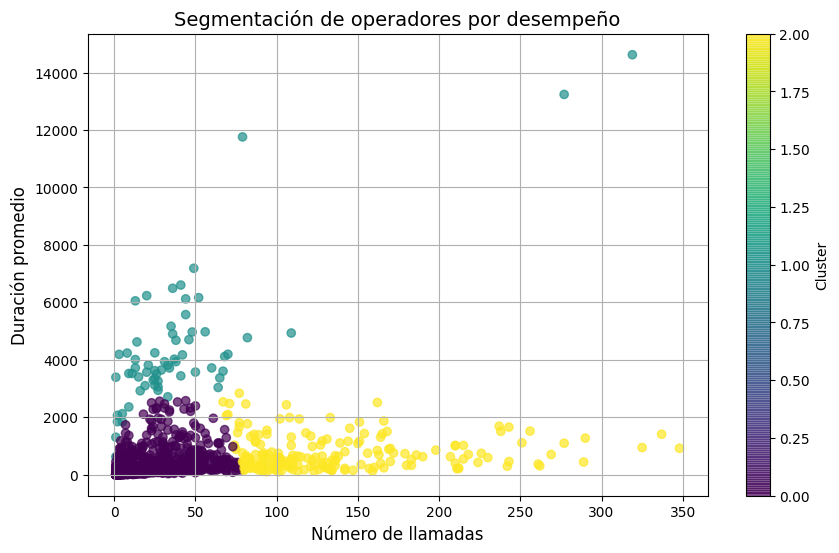

In [34]:
plt.figure(figsize=(10,6))

# Crear scatter
scatter = plt.scatter(
    metricas['num_llamadas'],
    metricas['duracion_promedio'],
    c=metricas['cluster'],
    cmap='viridis',     # colores más claros
    alpha=0.7           # transparencia
)

# Etiquetas de ejes
plt.xlabel("Número de llamadas", fontsize=12)
plt.ylabel("Duración promedio", fontsize=12)

# Título
plt.title("Segmentación de operadores por desempeño", fontsize=14)

# Barra de color (leyenda de clusters)
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Grid para mejor lectura
plt.grid(True)

plt.show()

Se visualizó la segmentación de operadores mediante clustering, identificando grupos diferenciados según su volumen de llamadas y duración promedio.

### **5.5.Identificar cluster de bajo rendimiento**

In [35]:
# Cluster con mayor score de ineficiencia
cluster_ineficiente = clusters_summary['score_ineficiencia'].idxmax()

print(f"🟢Cluster más ineficiente: {cluster_ineficiente}")

# Filtrar operadores de ese cluster
operadores_cluster_critico = metricas[
    metricas['cluster'] == cluster_ineficiente
]

display(operadores_cluster_critico.head())

🟢Cluster más ineficiente: 1


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria,cluster
28,"885,876.00",319,"14,620.55",4663954,45.83,Promedio,1
29,"885,890.00",277,"13,238.75",3667133,47.79,Promedio,1
74,"891,192.00",1,"1,306.00",1306,"1,306.00",Ineficiente,1
140,"896,386.00",2,"2,068.00",4136,"1,034.00",Ineficiente,1
149,"897,894.00",5,"1,846.00",9230,369.20,Ineficiente,1


El análisis de clustering permitió identificar patrones ocultos en el desempeño de los operadores, destacando un grupo de bajo rendimiento con características comunes. Esta segmentación facilita la toma de decisiones al enfocar esfuerzos de mejora en segmentos específicos en lugar de abordar a todos los operadores de manera uniforme.

# **6.Identificación de Operadores Ineficaces**

### **6.1.Aplicar criterios definidos**

In [36]:
# Filtrar operadores clasificados como ineficientes
operadores_ineficientes = metricas[
    metricas['categoria'] == 'Ineficiente'
]

# Ver resultados
print("🔴 Operadores ineficientes identificados:")
display(operadores_ineficientes.head())

🔴 Operadores ineficientes identificados:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria,cluster
55,"890,234.00",1,85.00,85,85.00,Ineficiente,0
74,"891,192.00",1,"1,306.00",1306,"1,306.00",Ineficiente,1
75,"891,250.00",1,110.00,110,110.00,Ineficiente,0
91,"891,970.00",3,368.67,1106,122.89,Ineficiente,0
139,"896,384.00",4,866.00,3464,216.50,Ineficiente,0


### **6.2.Crear ranking de operadores**

In [37]:
# Ordenar operadores de mayor a menor ineficiencia
ranking_ineficientes = metricas.sort_values(
    by='score_ineficiencia',
    ascending=False
)

# Seleccionar top 10
top_10_ineficientes = ranking_ineficientes.head(10)

print("🔴 Top 10 operadores más ineficientes:")
display(top_10_ineficientes)

🔴 Top 10 operadores más ineficientes:


,operator_id,num_llamadas,duracion_promedio,duracion_total,score_ineficiencia,categoria,cluster
326,"909,452.00",1,"3,394.00",3394,"3,394.00",Ineficiente,1
1073,"969,600.00",3,"4,190.00",12570,"1,396.67",Ineficiente,1
74,"891,192.00",1,"1,306.00",1306,"1,306.00",Ineficiente,1
140,"896,386.00",2,"2,068.00",4136,"1,034.00",Ineficiente,1
547,"925,134.00",2,"1,847.50",3695,923.75,Ineficiente,1
169,"899,906.00",1,626.00,626,626.00,Ineficiente,1
731,"938,070.00",8,"4,235.62",33885,529.45,Ineficiente,1
1053,"965,544.00",13,"6,053.92",78701,465.69,Ineficiente,1
945,"952,292.00",1,451.00,451,451.00,Ineficiente,0
1084,"971,102.00",5,"2,125.60",10628,425.12,Ineficiente,1


### **6.3.Análisis de características**

In [38]:
# Promedios generales
promedios = metricas.mean(numeric_only=True)

# Promedios de operadores ineficientes
promedios_ineficientes = operadores_ineficientes.mean(numeric_only=True)

# Comparación
comparacion = pd.DataFrame({
    'Promedio general': promedios,
    'Operadores ineficientes': promedios_ineficientes
})

print("📊 Comparación de métricas:")
display(comparacion)

📊 Comparación de métricas:


,Promedio general,Operadores ineficientes
operator_id,"925,517.54","931,564.45"
num_llamadas,41.88,15.03
duracion_promedio,648.21,"2,306.48"
duracion_total,"42,286.23","63,601.12"
score_ineficiencia,38.36,241.97
cluster,0.42,0.46


Se identificó un grupo específico de operadores con bajo desempeño, caracterizado por altos tiempos de atención y menor eficiencia relativa. Estos resultados permiten enfocar estrategias de mejora en casos puntuales, optimizando recursos y procesos.

# **7.Recomendaciones y Plan de Acción**

### **7.1.Propuestas de mejora**

🚨 Enfocadas en operadores ineficientes

Se recomienda implementar acciones específicas para los operadores identificados con bajo desempeño:

Reducir la duración promedio de llamadas mediante optimización de procesos
Estandarizar protocolos de atención para evitar tiempos innecesarios
Implementar guías rápidas o scripts de resolución

👉 Objetivo:

Mejorar la eficiencia sin afectar la calidad del servicio.

⚙️ Mejora de procesos operativos
Identificar cuellos de botella en las llamadas largas
Automatizar tareas repetitivas
Revisar flujos de atención

👉 Insight clave:

El problema no es la carga, es la gestión del tiempo

### **7.2.Estrategias de capacitación**

🎓 Capacitación dirigida (NO general)

Basada en los hallazgos del análisis:

-Entrenamiento en gestión del tiempo en llamadas

-Mejores prácticas de resolución rápida

-Simulación de casos reales



👥 Aprendizaje entre operadores

-Identificar operadores eficientes

-Usarlos como referencia o mentores

👉 Estrategia:

Transferencia de buenas prácticas

### **7.3.Métricas de seguimiento**

📊 KPIs a monitorear

-Duración promedio de llamadas

-Score de ineficiencia

-Número de llamadas atendidas


📅 Frecuencia de evaluación

-Seguimiento semanal o mensual

-Comparación antes vs después de mejoras


🎯 Objetivo de mejora

Reducir el score de ineficiencia en los operadores críticos en un porcentaje definido (ej: 15–20%)

A través del análisis de datos de telecomunicaciones, se logró evaluar el desempeño de los operadores mediante la definición de métricas clave enfocadas en productividad y gestión del tiempo.

Los resultados evidencian que la ineficiencia no está relacionada con el volumen de llamadas atendidas, sino principalmente con la duración promedio de las mismas, lo que indica oportunidades de mejora en la forma en que se gestionan las interacciones con los clientes.

Mediante el análisis exploratorio, la comparación de métricas y la segmentación de operadores, se identificó un grupo específico con bajo desempeño, caracterizado por altos tiempos de atención y menor eficiencia relativa.

La aplicación de técnicas de clustering permitió reforzar estos hallazgos al agrupar operadores con comportamientos similares, destacando un segmento crítico que requiere atención prioritaria.

# **8.Entregables**

### **8.1. Drive(presentación en pdf)**

https://drive.google.com/file/d/1fuKGiHB3hjV4uv1SdVafm-VL0mrQW5Gv/view?usp=sharing

### **8.2.Dashboard**

https://public.tableau.com/app/profile/juan.vega7639/viz/Telecomunicaciones-identificaroperadoresineficaces/AnlisisdeOperadoresTelecom?publish=yes